<a href="https://colab.research.google.com/github/HiveCase/DLCV/blob/main/Assignments/Week5/Week_5_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Welcome to Week-5 Assignment on Deep Learning for Computer Vision.**

This assignment is based on the content you learned in Week-5 of course.


#### **Instructions**
1. Use Python 3.x to run this notebook
2. Write your code only in between the lines 'YOUR CODE STARTS HERE' and 'YOUR CODE ENDS HERE'.
you should not change anything else in the code cells, if you do, the answers you are supposed to get at the end of this assignment might be wrong.
3. Read documentation of each function carefully.
4. All the Best!

##MNIST classification using CNN

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torch.nn.functional as F
import timeit
import unittest

## Please DONOT remove these lines.
torch.manual_seed(2024)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(2024)

### Data Loading and Pre-processing

In [2]:
# check availability of GPU and set the device accordingly
#### YOUR CODE STARTS HERE ####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#### YOUR CODE ENDS HERE ####

# Hyper parameters
num_epochs = 10
num_classes = 10
learning_rate = 0.001

# define a transforms for preparing the dataset
# for normalization of the MNIST dataset, take mean=0.1307 and std=0.3081

#### YOUR CODE STARTS HERE ####
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])
#### YOUR CODE ENDS HERE ####

In [3]:
# Load the MNIST training, test datasets using `torchvision.datasets.MNIST` using the transform defined above
#### YOUR CODE STARTS HERE ####
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)
#### YOUR CODE ENDS HERE ####

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.31MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.68MB/s]


In [4]:
from torch.utils.data import DataLoader
# create dataloaders for training and test datasets
# use a batch size of 32 and set shuffle=True for the training set
#### YOUR CODE STARTS HERE ####
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)
#### YOUR CODE ENDS HERE ####


### Network Definition

In [5]:
# Convolutional neural network (Two convolutional layers)
class ConvolutionNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ConvolutionNet, self).__init__()

        # Conv Block 1
        #### YOUR CODE STARTS HERE ####
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        #### YOUR CODE ENDS HERE ####

        # Conv Block 2
        #### YOUR CODE STARTS HERE ####
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        #### YOUR CODE ENDS HERE ####

        # Fully connected layer
        #### YOUR CODE STARTS HERE ####
        self.fc = nn.Linear(16 * 7 * 7, num_classes)
        #### YOUR CODE ENDS HERE ####

    def forward(self, x):
        #### YOUR CODE STARTS HERE ####
        output = self.conv_block1(x)
        output = self.conv_block2(output)

        # Reshape appropriately
        output = output.view(output.size(0), -1)

        output = self.fc(output)
        #### YOUR CODE ENDS HERE ####
        return output

In [6]:
model = ConvolutionNet(num_classes).to(device)
model.conv_block2[0].weight.shape

torch.Size([16, 32, 7, 7])

### Question 1

What is the size of parameter matrix corresponding to convolution layer of second sequential block ?

1. 32x16x5x5
2. 32x32x6x6
3. 16x32x7x7
4. 32x16x4x4


### Training and Inference

In [7]:
#### YOUR CODE STARTS HERE ####
model = ConvolutionNet(num_classes=num_classes).to(device)
#### YOUR CODE ENDS HERE ####


#### YOUR CODE STARTS HERE ####
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#### YOUR CODE ENDS HERE ####

# Train the model
total_step = len(train_dataloader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_dataloader):

        #### YOUR CODE STARTS HERE ####
        # send the image, target to the device
        images = images.to(device)
        labels = labels.to(device)

        # flush out the gradients stored in optimizer
        optimizer.zero_grad()

        # pass the image to the model and assign the output to variable named output
        output = model(images)

        # calculate the loss (use cross entropy in pytorch)
        loss = criterion(output, labels)

        # do a backward pass
        loss.backward()

        # update the weights
        optimizer.step()
        #### YOUR CODE ENDS HERE ####

        if (i+1) % 100 == 0:
            print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                  .format(epoch+1, num_epochs, i+1, total_step, loss.item()))

# Test the model
model.eval()  # eval mode
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_dataloader:

        #### YOUR CODE STARTS HERE ####
        # send the image, target to the device
        images = images.to(device)
        labels = labels.to(device)

        # pass the image to the model and assign the output to variable named output
        outputs = model(images)
        #### YOUR CODE ENDS HERE ####

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Test Accuracy of the model : {} %'.format(100 * correct / total))

Epoch [1/10], Step [100/1875], Loss: 0.1825
Epoch [1/10], Step [200/1875], Loss: 0.2177
Epoch [1/10], Step [300/1875], Loss: 0.1681
Epoch [1/10], Step [400/1875], Loss: 0.1042
Epoch [1/10], Step [500/1875], Loss: 0.0941
Epoch [1/10], Step [600/1875], Loss: 0.0331
Epoch [1/10], Step [700/1875], Loss: 0.0644
Epoch [1/10], Step [800/1875], Loss: 0.1339
Epoch [1/10], Step [900/1875], Loss: 0.0644
Epoch [1/10], Step [1000/1875], Loss: 0.0107
Epoch [1/10], Step [1100/1875], Loss: 0.0056
Epoch [1/10], Step [1200/1875], Loss: 0.0052
Epoch [1/10], Step [1300/1875], Loss: 0.0258
Epoch [1/10], Step [1400/1875], Loss: 0.0240
Epoch [1/10], Step [1500/1875], Loss: 0.0034
Epoch [1/10], Step [1600/1875], Loss: 0.0063
Epoch [1/10], Step [1700/1875], Loss: 0.0048
Epoch [1/10], Step [1800/1875], Loss: 0.0085
Epoch [2/10], Step [100/1875], Loss: 0.0144
Epoch [2/10], Step [200/1875], Loss: 0.0100
Epoch [2/10], Step [300/1875], Loss: 0.0045
Epoch [2/10], Step [400/1875], Loss: 0.0082
Epoch [2/10], Step [500

#### Question-2

Report the final test accuracy displayed above (If you are not getting the exact number shown in options, please report the closest number).
1. 84%
2. 76%
3. 99%
4. 57%


#### Question-3

Report the loss value at the step 1800? (If you are not getting the exact number shown in options, please report the closest number).
1. 0.0042
2. 0.15
3. 0.00065
4. 1.4


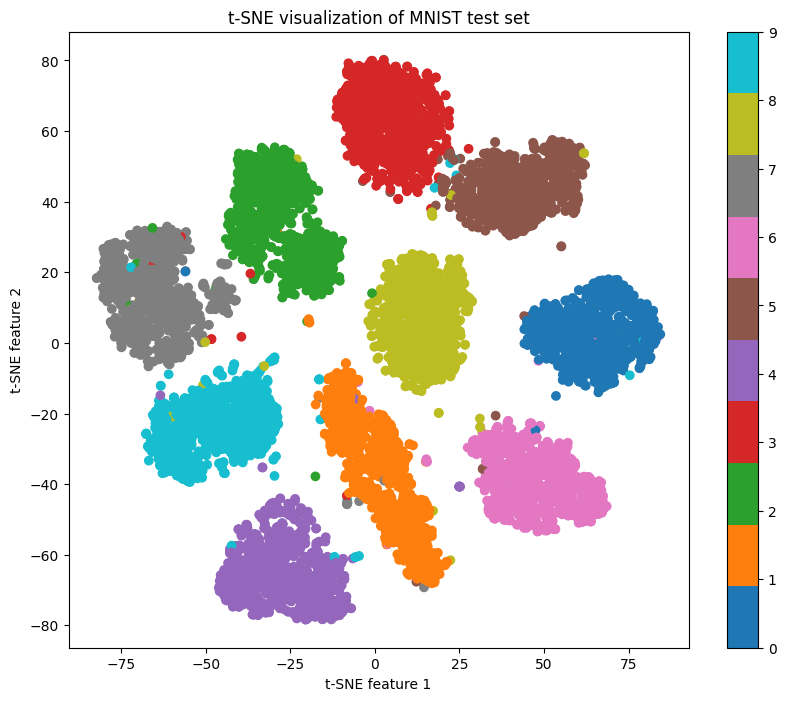

In [8]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import numpy as np

# Create a Function to get embeddings
def get_embeddings(model, dataloader, device):
    # YOUR CODE STARTS HERE
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for images, batch_labels in dataloader:
            # Send images to GPU
            images = images.to(device)

            # Get the output of the second-to-last layer (before the final fully connected layer)
            embedding = model.conv_block2(model.conv_block1(images))

            # Flatten the embedding
            embedding = embedding.view(embedding.size(0), -1)

            # Append the embedding and labels to the lists
            embeddings.append(embedding.cpu().numpy())
            labels.append(batch_labels.numpy())

    # YOUR CODE ENDS HERE
    return np.vstack(embeddings), np.concatenate(labels)

# Get embeddings for the test set
test_embeddings, test_labels = get_embeddings(model, test_dataloader, device)

# Apply t-SNE

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(test_embeddings)

# Visualize the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=test_labels, cmap='tab10')
plt.colorbar(scatter)
plt.title('t-SNE visualization of MNIST test set')
plt.xlabel('t-SNE feature 1')
plt.ylabel('t-SNE feature 2')
plt.show()

In [23]:
import numpy as np
from scipy.spatial.distance import cdist

# Compute centroid of each digit
centroids = np.array([
    test_embeddings[test_labels == i].mean(axis=0)
    for i in range(10)
])

# Pairwise distances
dist = cdist(centroids, centroids, metric="euclidean")

print(np.round(dist, 2))

[[ 0.   21.59 17.67 19.36 21.12 18.54 18.33 20.03 18.6  19.55]
 [21.59  0.   18.55 20.71 16.18 20.34 20.85 17.46 19.39 20.13]
 [17.67 18.55  0.   16.39 19.31 19.95 20.56 17.78 15.93 19.74]
 [19.36 20.71 16.39  0.   20.66 14.11 21.26 18.86 16.3  18.88]
 [21.12 16.18 19.31 20.66  0.   18.71 18.43 18.66 19.59 13.99]
 [18.54 20.34 19.95 14.11 18.71  0.   18.69 19.41 15.54 16.86]
 [18.33 20.85 20.56 21.26 18.43 18.69  0.   24.5  20.89 22.32]
 [20.03 17.46 17.78 18.86 18.66 19.41 24.5   0.   18.6  14.18]
 [18.6  19.39 15.93 16.3  19.59 15.54 20.89 18.6   0.   16.7 ]
 [19.55 20.13 19.74 18.88 13.99 16.86 22.32 14.18 16.7   0.  ]]


In [24]:
centroids_tsne = np.array([
    tsne_results[test_labels == i].mean(axis=0)
    for i in range(10)
])

dist_tsne = cdist(centroids_tsne, centroids_tsne)

print(np.round(dist_tsne, 2))

[[  0.    74.59  97.12  84.62 112.97  46.94  44.68 128.96  51.45 113.71]
 [ 74.59   0.    76.58  99.45  38.86  90.98  45.7   82.77  45.44  49.8 ]
 [ 97.12  76.58   0.    42.8   97.6   70.67 103.86  41.72  48.87  59.71]
 [ 84.62  99.45  42.8    0.   129.91  42.11 109.42  83.99  56.21  99.13]
 [112.97  38.86  97.6  129.91   0.   128.21  78.14  85.86  81.14  45.32]
 [ 46.94  90.98  70.67  42.11 128.21   0.    82.7  110.7   47.4  111.15]
 [ 44.68  45.7  103.86 109.42  78.14  82.7    0.   122.68  56.52  94.69]
 [128.96  82.77  41.72  83.99  85.86 110.7  122.68   0.    77.51  40.53]
 [ 51.45  45.44  48.87  56.21  81.14  47.4   56.52  77.51   0.    66.48]
 [113.71  49.8   59.71  99.13  45.32 111.15  94.69  40.53  66.48   0.  ]]


#### Question-4

Embedding of which class/digit is closest to the embedding of 7?
1. 3
2. 5
3. 8
4. 1


In [25]:
import numpy as np

# Compute centroid for each digit
centroids = {}
for digit in range(10):
    centroids[digit] = test_embeddings[test_labels == digit].mean(axis=0)

# Options given in the question
options = [3, 5, 8, 1]

print("Distances from digit 7:")
distances = {}

for digit in options:
    dist = np.linalg.norm(centroids[7] - centroids[digit])
    distances[digit] = dist
    print(f"7 -> {digit}: {dist:.4f}")

closest = min(distances, key=distances.get)
print("\nClosest digit to 7:", closest)

Distances from digit 7:
7 -> 3: 18.8622
7 -> 5: 19.4111
7 -> 8: 18.6008
7 -> 1: 17.4608

Closest digit to 7: 1


In [21]:
d

array([20.02573245, 17.46084724, 17.77800886, 18.86225057, 18.65850817,
       19.41107311, 24.49876312,         inf, 18.60077551, 14.18345232])

In [16]:
# Closest to 7
d = dist_tsne[7].copy()
d[7] = np.inf
print("Closest to 7:", np.argmin(d))

Closest to 7: 9


#### Question-5

Embedding of which class/digit is farthest to the embedding of 4?
1. 1
2. 6
3. 9
4. 3


In [17]:
# Farthest digit from 4
d = dist[4].copy()
d[4] = -np.inf
farthest = np.argmax(d)

print("Farthest from 4:", farthest)

Farthest from 4: 0


In [18]:
# Farthest from 4
d = dist_tsne[4].copy()
d[4] = -np.inf
print("Farthest from 4:", np.argmax(d))

Farthest from 4: 3


shape of the filters is: (32, 1, 5, 5)


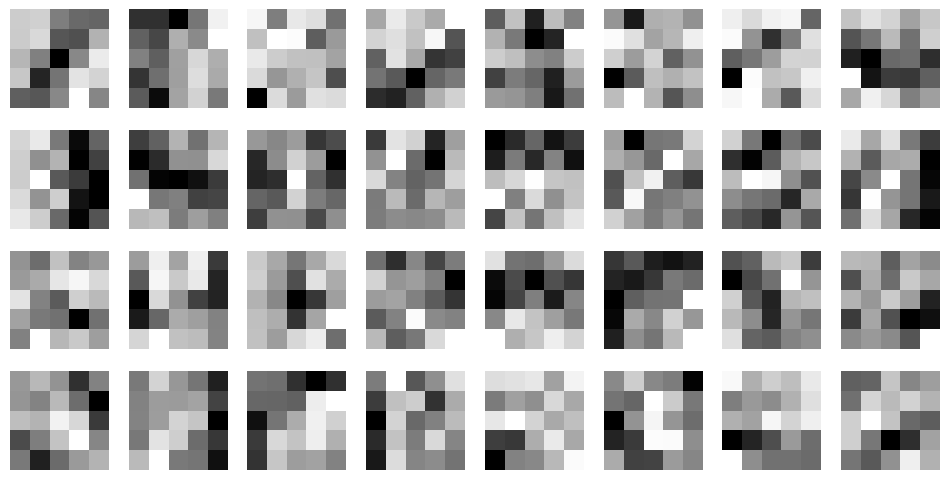

In [19]:
import matplotlib.pyplot as plt

# Get the weights of the first convolutional layer
#YOUR CODE STARTS HERE
filters = model.conv_block1[0].weight.data.cpu().numpy()
#YOUR CODE ENDS HERE

print(f"shape of the filters is: {filters.shape}")

# Normalize the filters for better visualization
min_val = filters.min()
max_val = filters.max()
filters = (filters - min_val) / (max_val - min_val)

# Plot the filters
fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < filters.shape[0]:
        # Each filter is in the shape of (out_channels, in_channels, height, width)
        # We take the first in_channel (0) since it's grayscale, so only one channel exists
        ax.imshow(filters[i, 0, :, :], cmap='gray')
        ax.axis('off')
    else:
        ax.axis('off')

plt.show()


#### Question-6

What is the shape of filters?
1. (32,16 , 5, 5)
2. (32, 1, 5, 5)
3. (16, 32, 5, 5)
4. (16, 1)
